# Oxygen-centered multivariable geometry of the periodic table

This notebook analyzes a 118-element periodic table representation in a shared multivariable chemical space.

Main goals:
1. Build oxygen-centered rankings in 2D and 3D PCA space.
2. Test robustness across alternative model variants.
3. Compare oxygen-centered geometry with carbon, nitrogen, hydrogen, and sulfur.
4. Evaluate whether oxygen defines a distinctive local neighborhood.

## Notebook structure

1. Load dataset  
2. Build PCA spaces  
3. Compute oxygen-centered ranking  
4. Compare alternative reference elements  
5. Evaluate oxygen vs sulfur geometry  
6. Export figures and tables

In [1]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import spearmanr
from google.colab import files

plt.rcParams["figure.dpi"] = 140
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## 1. Load the 118-element dataset

## Input file

This notebook expects the file:

`oxygen_centered_interpretable_final_118.csv`

Upload that file when prompted.

In [2]:
uploaded = files.upload()
print(os.listdir())

Saving oxygen_centered_interpretable_final_118.csv to oxygen_centered_interpretable_final_118.csv
['.config', 'oxygen_centered_interpretable_final_118.csv', 'sample_data']


In [3]:
DATA_FILENAME = list(uploaded.keys())[0]
print("Using file:", DATA_FILENAME)

df_master = pd.read_csv(DATA_FILENAME)

print("Rows:", len(df_master))
print("Unique elements:", df_master["element"].nunique())
print("Columns:", len(df_master.columns))
display(df_master.head())

Using file: oxygen_centered_interpretable_final_118.csv
Rows: 118
Unique elements: 118
Columns: 14


,element,name,regime_label,oxygen_relation_class_3d,distance_to_oxygen_3d,oxygen_similarity_score_3d,oxygen_compatibility_index,oxygen_affinity_proxy,redox_flexibility_proxy,electronegativity,electron_affinity,ionization_energy_1,group,period
0,O,Oxygen,buffer / catalytic regime,oxygen-core,0.000000,1.000000,0.964706,1.00,0.80,3.44,1.461,13.618,16,2
1,S,Sulfur,buffer / catalytic regime,oxygen-near,1.455016,0.857701,0.845139,0.85,0.75,2.58,2.077,10.360,16,3
2,I,Iodine,strong binding / low flexibility regime,oxygen-near,1.477016,0.855550,0.718808,0.82,0.42,2.66,3.059,10.451,17,5
3,Cl,Chlorine,strong binding / low flexibility regime,oxygen-near,1.577976,0.845676,0.695800,0.78,0.40,3.16,3.613,12.968,17,3
4,Br,Bromine,structural / support regime,oxygen-near,1.626778,0.840903,0.674832,0.74,0.38,2.96,3.365,11.814,17,4


## 2. Build PCA spaces

In [4]:
pca_features = [
    "electronegativity",
    "electron_affinity",
    "ionization_energy_1",
    "oxygen_affinity_proxy",
    "redox_flexibility_proxy",
    "group",
    "period"
]

print("PCA features:", pca_features)

PCA features: ['electronegativity', 'electron_affinity', 'ionization_energy_1', 'oxygen_affinity_proxy', 'redox_flexibility_proxy', 'group', 'period']


In [5]:
X = df_master[pca_features].copy()

scaler_2d = StandardScaler()
X_scaled_2d = scaler_2d.fit_transform(X)

pca_2d = PCA(n_components=2)
coords_2d = pca_2d.fit_transform(X_scaled_2d)

df_master["pca1_2d"] = coords_2d[:, 0]
df_master["pca2_2d"] = coords_2d[:, 1]

print("Explained variance ratio (2D):")
print(pca_2d.explained_variance_ratio_)
print("Total explained (2D):", pca_2d.explained_variance_ratio_.sum())

Explained variance ratio (2D):
[0.42897528 0.28045509]
Total explained (2D): 0.7094303637867929


In [6]:
scaler_3d = StandardScaler()
X_scaled_3d = scaler_3d.fit_transform(X)

pca_3d = PCA(n_components=3)
coords_3d = pca_3d.fit_transform(X_scaled_3d)

df_master["pca1_3d"] = coords_3d[:, 0]
df_master["pca2_3d"] = coords_3d[:, 1]
df_master["pca3_3d"] = coords_3d[:, 2]

print("Explained variance ratio (3D):")
print(pca_3d.explained_variance_ratio_)
print("Total explained (3D):", pca_3d.explained_variance_ratio_.sum())

Explained variance ratio (3D):
[0.42897528 0.28045509 0.10495437]
Total explained (3D): 0.8143847371742374


In [7]:
display(
    df_master[
        [
            "element",
            "name",
            "pca1_2d",
            "pca2_2d",
            "pca1_3d",
            "pca2_3d",
            "pca3_3d"
        ]
    ].head(10)
)

,element,name,pca1_2d,pca2_2d,pca1_3d,pca2_3d,pca3_3d
0,O,Oxygen,4.306935,1.959255,4.306935,1.959255,-0.571757
1,S,Sulfur,3.001842,1.368102,3.001842,1.368102,-0.825417
2,I,Iodine,3.297101,0.941002,3.297101,0.941002,-0.218238
3,Cl,Chlorine,4.667166,0.527462,4.667166,0.527462,-1.128724
4,Br,Bromine,3.957771,0.372254,3.957771,0.372254,-0.648705
5,Se,Selenium,2.610947,1.309684,2.610947,1.309684,-0.362052
6,Te,Tellurium,1.919303,1.336902,1.919303,1.336902,-0.069074
7,At,Astatine,2.370726,0.480142,2.370726,0.480142,0.188193
8,C,Carbon,2.749147,-0.224156,2.749147,-0.224156,-0.926372
9,Au,Gold,1.658538,1.683142,1.658538,1.683142,-0.042274


## 3. Compute oxygen-centered distances in 2D and 3D space

In [8]:
oxygen_row = df_master[df_master["element"] == "O"].iloc[0]

oxygen_coords_2d = np.array([
    oxygen_row["pca1_2d"],
    oxygen_row["pca2_2d"]
])

oxygen_coords_3d = np.array([
    oxygen_row["pca1_3d"],
    oxygen_row["pca2_3d"],
    oxygen_row["pca3_3d"]
])

print("Oxygen 2D coordinates:", oxygen_coords_2d)
print("Oxygen 3D coordinates:", oxygen_coords_3d)

Oxygen 2D coordinates: [4.30693463 1.95925458]
Oxygen 3D coordinates: [ 4.30693463  1.95925458 -0.57175692]


In [9]:
df_master["distance_to_oxygen_2d"] = np.sqrt(
    (df_master["pca1_2d"] - oxygen_coords_2d[0])**2 +
    (df_master["pca2_2d"] - oxygen_coords_2d[1])**2
)

print(df_master["distance_to_oxygen_2d"].describe())

count    118.000000
mean       4.979533
std        1.606392
min        0.000000
25%        4.049034
50%        4.892307
75%        6.201164
max       10.225057
Name: distance_to_oxygen_2d, dtype: float64


In [10]:
df_master["distance_to_oxygen_3d"] = np.sqrt(
    (df_master["pca1_3d"] - oxygen_coords_3d[0])**2 +
    (df_master["pca2_3d"] - oxygen_coords_3d[1])**2 +
    (df_master["pca3_3d"] - oxygen_coords_3d[2])**2
)

print(df_master["distance_to_oxygen_3d"].describe())

count    118.000000
mean       5.087649
std        1.597945
min        0.000000
25%        4.156970
50%        5.168783
75%        6.220211
max       10.225070
Name: distance_to_oxygen_3d, dtype: float64


In [11]:
max_distance = df_master["distance_to_oxygen_3d"].max()

df_master["oxygen_similarity_score_3d"] = (
    1 - df_master["distance_to_oxygen_3d"] / max_distance
)

display(
    df_master[
        [
            "element",
            "name",
            "distance_to_oxygen_3d",
            "oxygen_similarity_score_3d"
        ]
    ].sort_values("distance_to_oxygen_3d").head(15)
)

,element,name,distance_to_oxygen_3d,oxygen_similarity_score_3d
0,O,Oxygen,0.000000,1.000000
1,S,Sulfur,1.455016,0.857701
2,I,Iodine,1.477016,0.855550
3,Cl,Chlorine,1.577976,0.845676
4,Br,Bromine,1.626778,0.840903
5,Se,Selenium,1.828194,0.821205
6,Te,Tellurium,2.518094,0.753733
7,At,Astatine,2.552293,0.750389
8,C,Carbon,2.705501,0.735405
9,Au,Gold,2.714884,0.734488


In [12]:
oxygen_rank_3d = df_master.sort_values(
    "distance_to_oxygen_3d"
).reset_index(drop=True)

oxygen_rank_3d["oxygen_rank_3d"] = oxygen_rank_3d.index + 1

display(
    oxygen_rank_3d[
        [
            "oxygen_rank_3d",
            "element",
            "name",
            "distance_to_oxygen_3d",
            "oxygen_similarity_score_3d"
        ]
    ].head(15)
)

,oxygen_rank_3d,element,name,distance_to_oxygen_3d,oxygen_similarity_score_3d
0,1,O,Oxygen,0.000000,1.000000
1,2,S,Sulfur,1.455016,0.857701
2,3,I,Iodine,1.477016,0.855550
3,4,Cl,Chlorine,1.577976,0.845676
4,5,Br,Bromine,1.626778,0.840903
5,6,Se,Selenium,1.828194,0.821205
6,7,Te,Tellurium,2.518094,0.753733
7,8,At,Astatine,2.552293,0.750389
8,9,C,Carbon,2.705501,0.735405
9,10,Au,Gold,2.714884,0.734488


In [13]:
top15_near = oxygen_rank_3d.head(15).copy()
top15_far = oxygen_rank_3d.tail(15).copy()

print("Top 15 nearest to oxygen")
display(
    top15_near[
        [
            "element",
            "name",
            "distance_to_oxygen_3d",
            "oxygen_similarity_score_3d"
        ]
    ]
)

print("Top 15 farthest from oxygen")
display(
    top15_far[
        [
            "element",
            "name",
            "distance_to_oxygen_3d",
            "oxygen_similarity_score_3d"
        ]
    ]
)

Top 15 nearest to oxygen


,element,name,distance_to_oxygen_3d,oxygen_similarity_score_3d
0,O,Oxygen,0.000000,1.000000
1,S,Sulfur,1.455016,0.857701
2,I,Iodine,1.477016,0.855550
3,Cl,Chlorine,1.577976,0.845676
4,Br,Bromine,1.626778,0.840903
5,Se,Selenium,1.828194,0.821205
6,Te,Tellurium,2.518094,0.753733
7,At,Astatine,2.552293,0.750389
8,C,Carbon,2.705501,0.735405
9,Au,Gold,2.714884,0.734488


Top 15 farthest from oxygen


,element,name,distance_to_oxygen_3d,oxygen_similarity_score_3d
103,Md,Mendelevium,6.515712,0.362771
104,Na,Sodium,6.544149,0.359990
105,Am,Americium,6.561850,0.358259
106,Yb,Ytterbium,6.633769,0.351225
107,Lr,Lawrencium,6.696346,0.345105
108,Ac,Actinium,6.703751,0.344381
109,Sr,Strontium,6.796367,0.335323
110,K,Potassium,6.862797,0.328826
111,Ba,Barium,7.048076,0.310706
112,Rb,Rubidium,7.060760,0.309466


## 4. Main oxygen-centered ranking figure

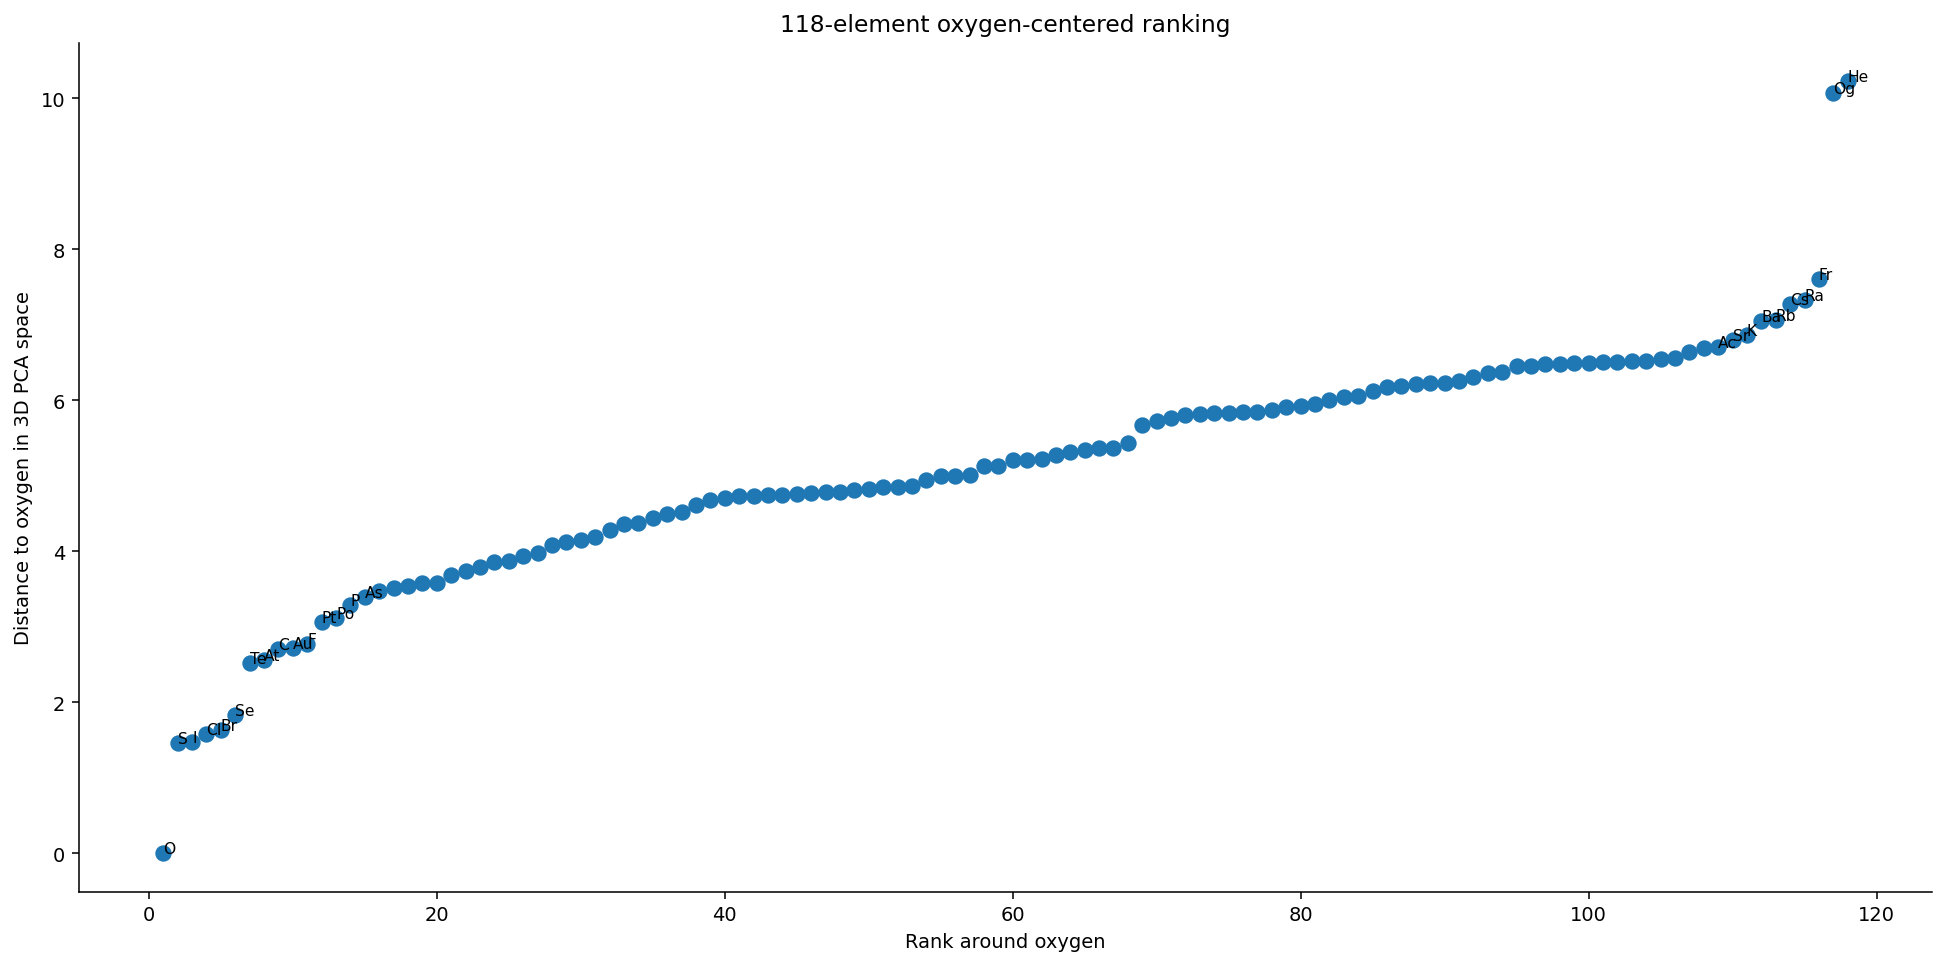

In [14]:
plt.figure(figsize=(14, 7))

plt.scatter(
    oxygen_rank_3d["oxygen_rank_3d"],
    oxygen_rank_3d["distance_to_oxygen_3d"],
    s=55
)

for _, row in oxygen_rank_3d.head(15).iterrows():
    plt.text(
        row["oxygen_rank_3d"],
        row["distance_to_oxygen_3d"],
        row["element"],
        fontsize=8
    )

for _, row in oxygen_rank_3d.tail(10).iterrows():
    plt.text(
        row["oxygen_rank_3d"],
        row["distance_to_oxygen_3d"],
        row["element"],
        fontsize=8
    )

plt.xlabel("Rank around oxygen")
plt.ylabel("Distance to oxygen in 3D PCA space")
plt.title("118-element oxygen-centered ranking")
plt.tight_layout()
plt.show()

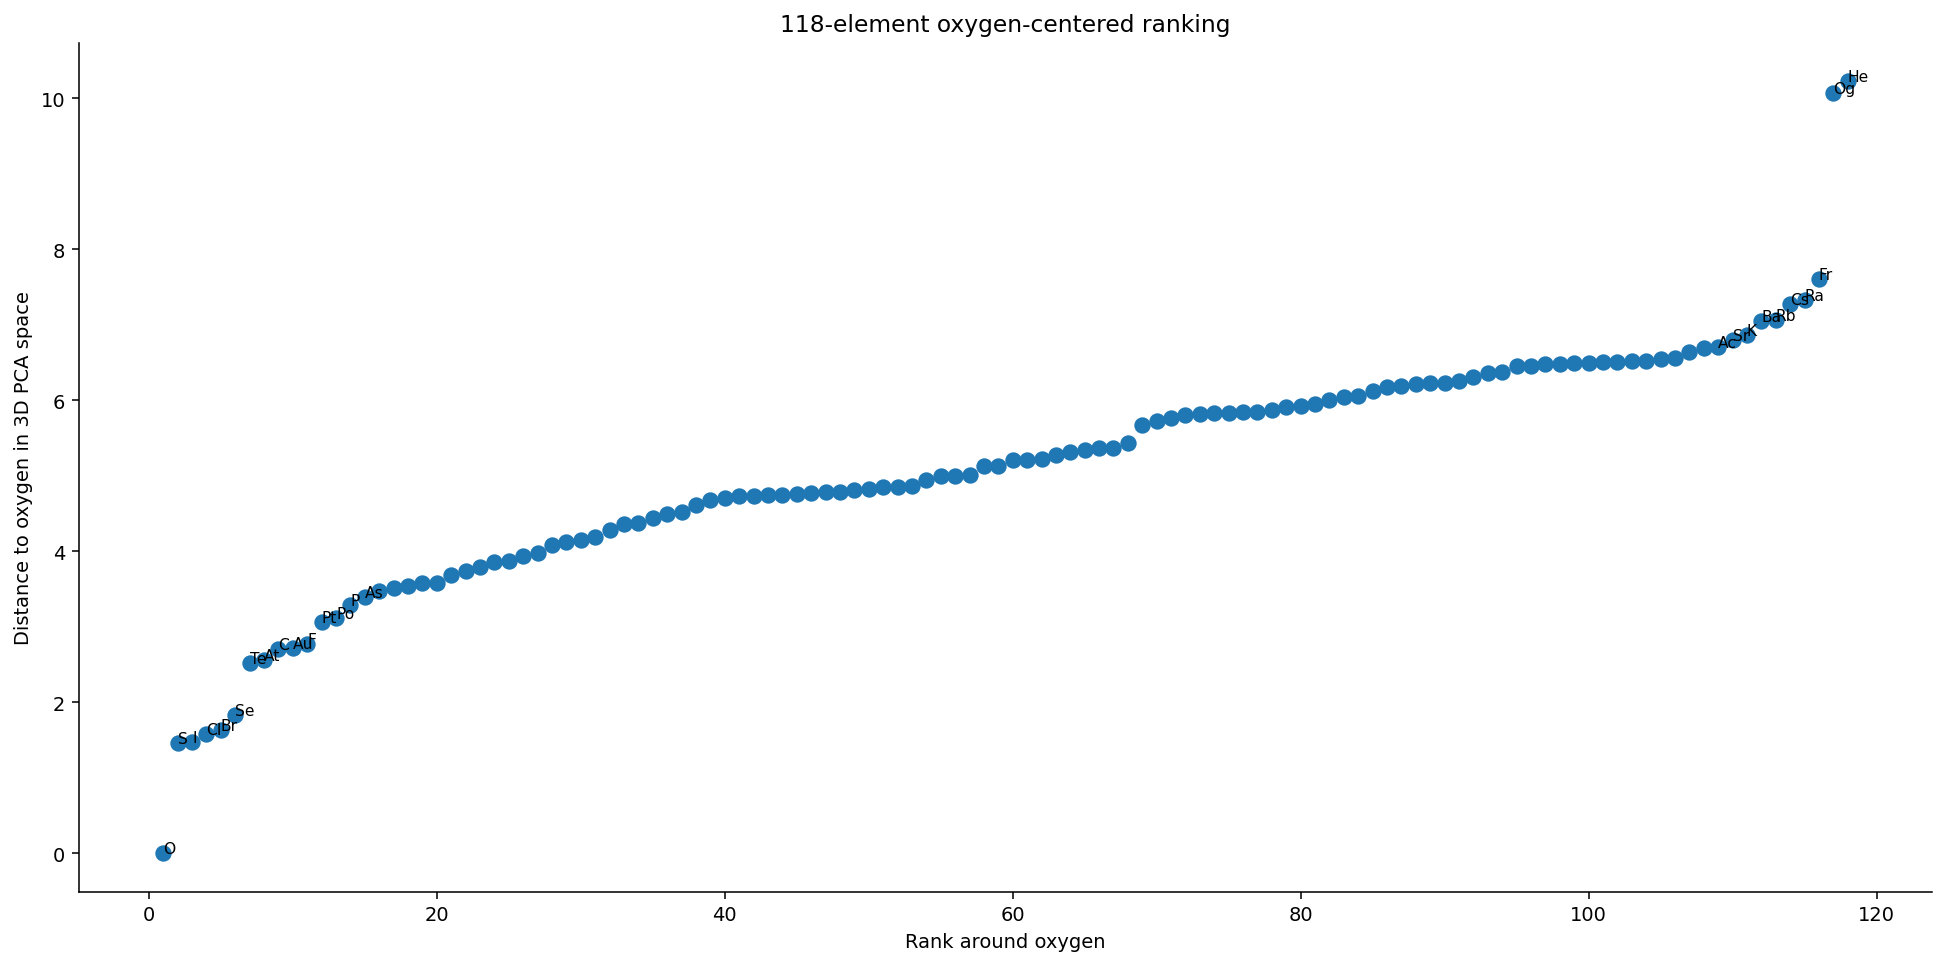

Saved:
- oxygen_centered_ranking_main.png
- oxygen_centered_ranking_main.pdf


In [15]:
plt.figure(figsize=(14, 7))

plt.scatter(
    oxygen_rank_3d["oxygen_rank_3d"],
    oxygen_rank_3d["distance_to_oxygen_3d"],
    s=55
)

for _, row in oxygen_rank_3d.head(15).iterrows():
    plt.text(
        row["oxygen_rank_3d"],
        row["distance_to_oxygen_3d"],
        row["element"],
        fontsize=8
    )

for _, row in oxygen_rank_3d.tail(10).iterrows():
    plt.text(
        row["oxygen_rank_3d"],
        row["distance_to_oxygen_3d"],
        row["element"],
        fontsize=8
    )

plt.xlabel("Rank around oxygen")
plt.ylabel("Distance to oxygen in 3D PCA space")
plt.title("118-element oxygen-centered ranking")
plt.tight_layout()

plt.savefig(
    "oxygen_centered_ranking_main.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "oxygen_centered_ranking_main.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print("- oxygen_centered_ranking_main.png")
print("- oxygen_centered_ranking_main.pdf")

## 5. Oxygen relation classes

In [16]:
def classify_oxygen_relation(distance):
    if distance == 0:
        return "oxygen-core"
    elif distance <= 2:
        return "oxygen-near"
    elif distance <= 4:
        return "oxygen-intermediate"
    else:
        return "oxygen-distant"

df_master["oxygen_relation_class_3d"] = df_master["distance_to_oxygen_3d"].apply(
    classify_oxygen_relation
)

df_master["oxygen_relation_class_3d"].value_counts()

,count
oxygen_relation_class_3d,
oxygen-distant,91
oxygen-intermediate,21
oxygen-near,5
oxygen-core,1


In [17]:
regime_summary = (
    df_master.groupby("regime_label")[
        ["oxygen_similarity_score_3d", "distance_to_oxygen_3d"]
    ]
    .mean()
    .sort_values("oxygen_similarity_score_3d", ascending=False)
)

display(regime_summary)

,oxygen_similarity_score_3d,distance_to_oxygen_3d
regime_label,,
strong binding / low flexibility regime,0.733779,2.722128
buffer / catalytic regime,0.617988,3.906101
structural / support regime,0.464780,5.472663
redox-active transition regime,0.414498,5.986797
outlier regime,0.375377,6.386814


In [18]:
oxygen_class_summary = pd.crosstab(
    df_master["oxygen_relation_class_3d"],
    df_master["regime_label"]
)

display(oxygen_class_summary)

regime_label,buffer / catalytic regime,outlier regime,redox-active transition regime,strong binding / low flexibility regime,structural / support regime
oxygen_relation_class_3d,,,,,
oxygen-core,1,0,0,0,0
oxygen-distant,16,7,24,1,43
oxygen-intermediate,10,0,1,4,6
oxygen-near,2,0,0,2,1


## 6. Export core oxygen-centered results

In [19]:
oxygen_rank_3d.to_csv("oxygen_centered_full_ranking.csv", index=False)
top15_near.to_csv("oxygen_top15_nearest.csv", index=False)
top15_far.to_csv("oxygen_top15_farthest.csv", index=False)
regime_summary.to_csv("oxygen_regime_summary.csv")
oxygen_class_summary.to_csv("oxygen_class_summary.csv")

print("Saved:")
print("- oxygen_centered_full_ranking.csv")
print("- oxygen_top15_nearest.csv")
print("- oxygen_top15_farthest.csv")
print("- oxygen_regime_summary.csv")
print("- oxygen_class_summary.csv")

Saved:
- oxygen_centered_full_ranking.csv
- oxygen_top15_nearest.csv
- oxygen_top15_farthest.csv
- oxygen_regime_summary.csv
- oxygen_class_summary.csv


## 7. Define a general ranking function for alternative reference elements

In [20]:
def build_reference_ranking(df, reference_element):
    ref_row = df[df["element"] == reference_element].iloc[0]

    ref_coords = np.array([
        ref_row["pca1_3d"],
        ref_row["pca2_3d"],
        ref_row["pca3_3d"]
    ])

    distances = np.sqrt(
        (df["pca1_3d"] - ref_coords[0])**2 +
        (df["pca2_3d"] - ref_coords[1])**2 +
        (df["pca3_3d"] - ref_coords[2])**2
    )

    ranked = df.copy()
    ranked[f"distance_to_{reference_element.lower()}_3d"] = distances

    max_dist = ranked[f"distance_to_{reference_element.lower()}_3d"].max()
    ranked[f"{reference_element.lower()}_similarity_score_3d"] = (
        1 - ranked[f"distance_to_{reference_element.lower()}_3d"] / max_dist
    )

    ranked = ranked.sort_values(
        f"distance_to_{reference_element.lower()}_3d"
    ).reset_index(drop=True)

    ranked[f"rank_around_{reference_element}"] = ranked.index + 1
    return ranked

## 8. Compare O, C, N, H, and S as reference elements

In [21]:
reference_elements = ["O", "C", "N", "H", "S"]

reference_rankings = {}
for ref in reference_elements:
    reference_rankings[ref] = build_reference_ranking(df_master, ref)

print("Built rankings for:", list(reference_rankings.keys()))

Built rankings for: ['O', 'C', 'N', 'H', 'S']


In [22]:
compactness_rows = []

for ref, ranked in reference_rankings.items():
    dist_col = f"distance_to_{ref.lower()}_3d"
    compactness_rows.append({
        "reference": ref,
        "mean_distance_top10": ranked[dist_col].head(10).mean(),
        "mean_distance_top20": ranked[dist_col].head(20).mean(),
        "top10_elements": ", ".join(ranked["element"].head(10).tolist())
    })

reference_compactness_df = pd.DataFrame(compactness_rows).sort_values(
    "mean_distance_top10"
)

display(reference_compactness_df)

,reference,mean_distance_top10,mean_distance_top20,top10_elements
4,S,1.215542,1.692048,"S, Se, I, Te, Br, O, At, Au, C, Cl"
1,C,1.283651,1.694503,"C, P, Si, At, Br, I, As, Ge, S, Se"
2,N,1.651552,2.164900,"N, Ar, Kr, Xe, Ne, B, Rn, C, P, Ge"
3,H,1.805097,2.277064,"H, B, Si, C, Be, Al, Ge, P, Mg, Ga"
0,O,1.845575,2.586899,"O, S, I, Cl, Br, Se, Te, At, C, Au"


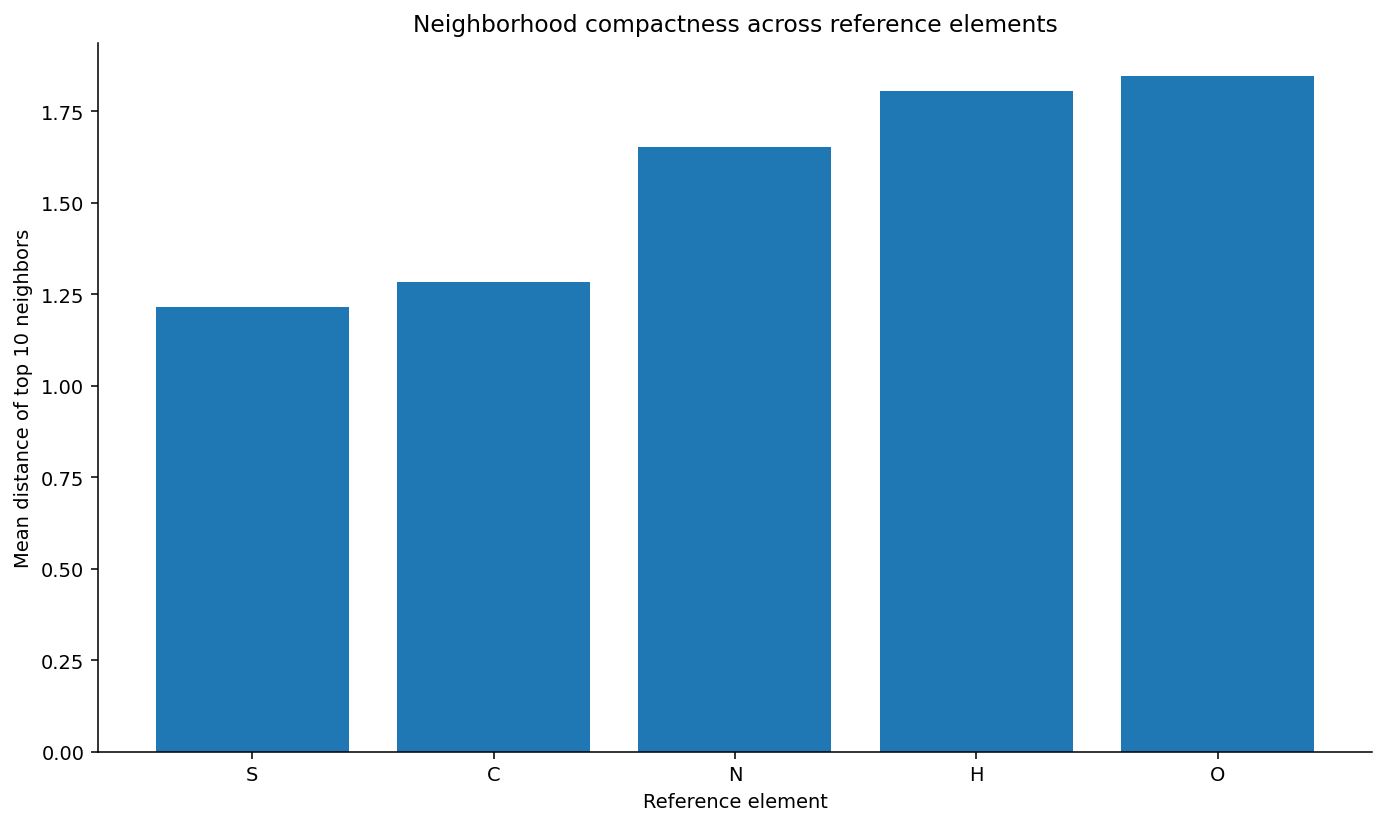

In [23]:
plt.figure(figsize=(10, 6))
plt.bar(
    reference_compactness_df["reference"],
    reference_compactness_df["mean_distance_top10"]
)
plt.xlabel("Reference element")
plt.ylabel("Mean distance of top 10 neighbors")
plt.title("Neighborhood compactness across reference elements")
plt.tight_layout()
plt.show()

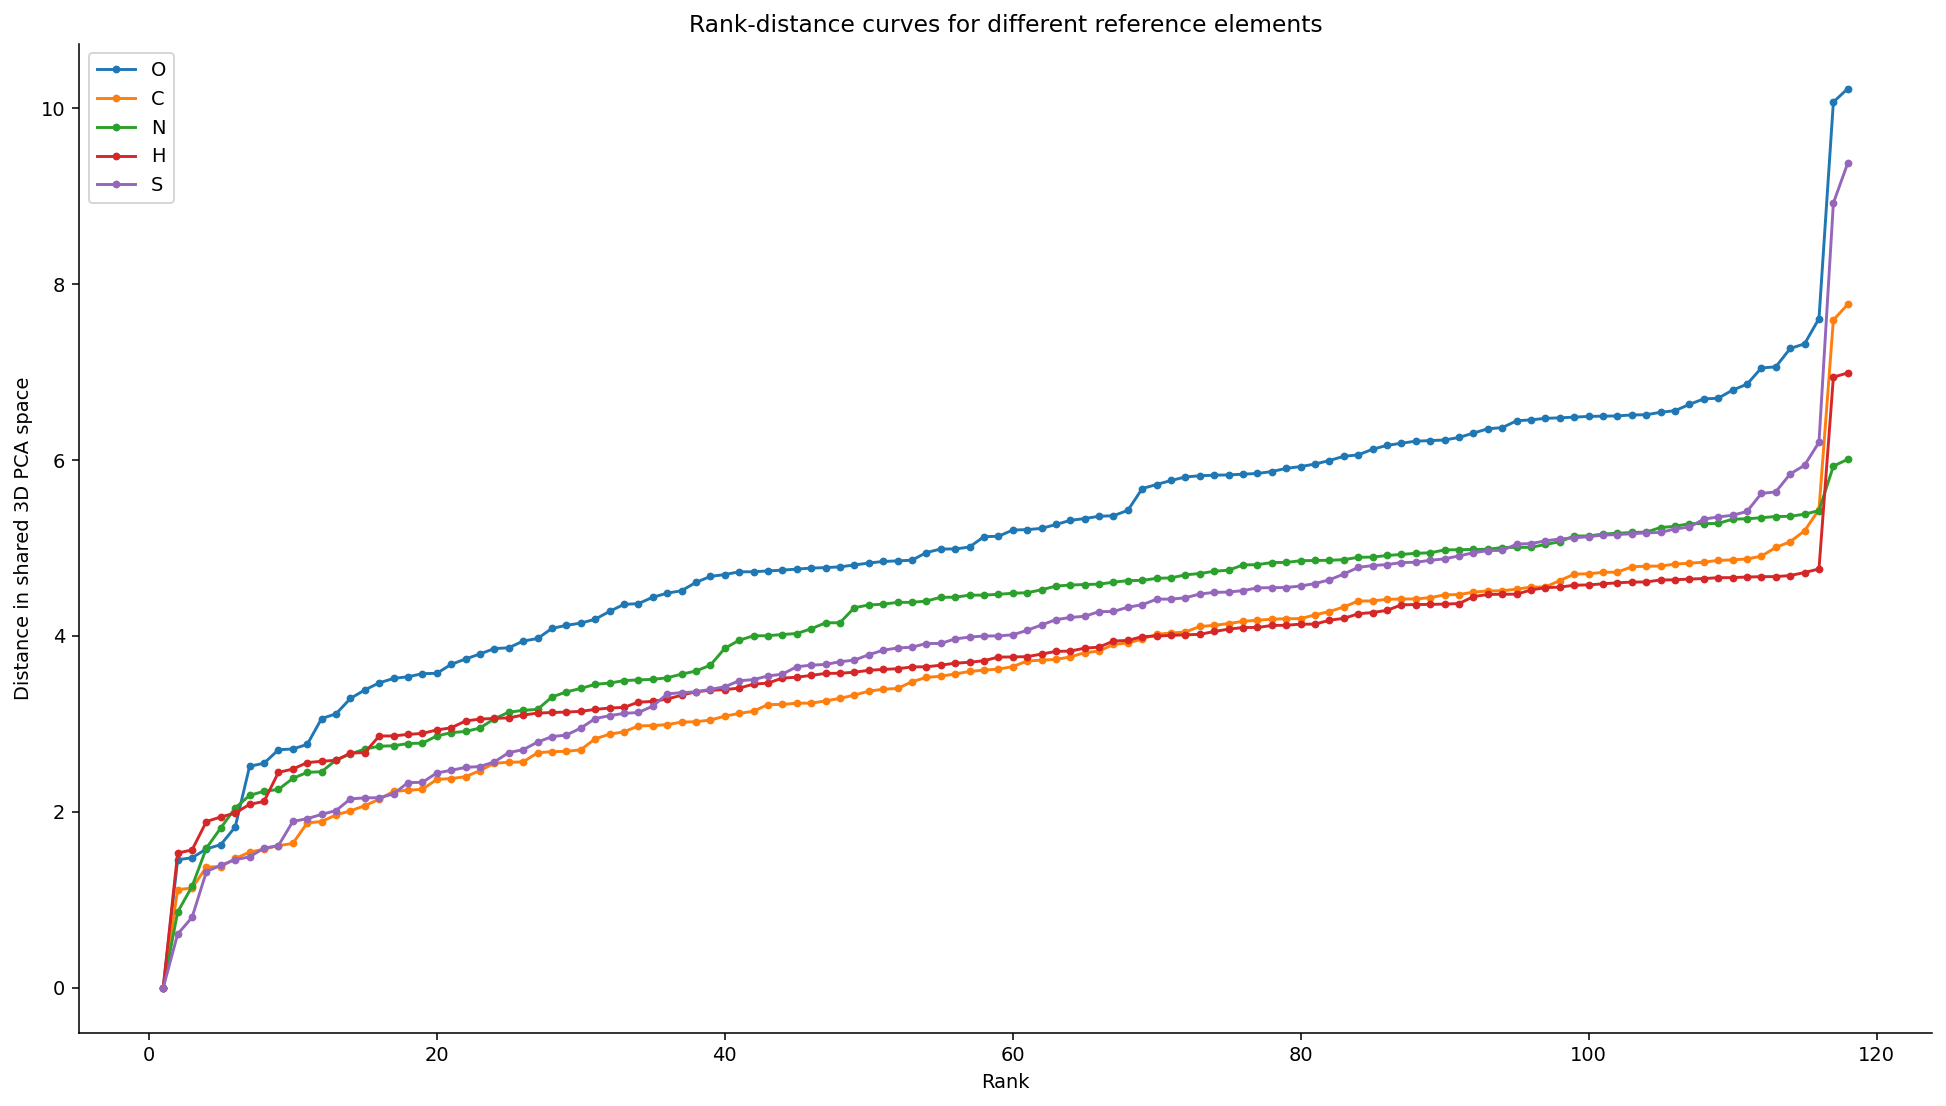

In [24]:
plt.figure(figsize=(14, 8))

for ref, ranked in reference_rankings.items():
    dist_col = f"distance_to_{ref.lower()}_3d"
    plt.plot(
        range(1, len(ranked) + 1),
        ranked[dist_col].values,
        marker="o",
        markersize=3,
        linewidth=1.5,
        label=ref
    )

plt.xlabel("Rank")
plt.ylabel("Distance in shared 3D PCA space")
plt.title("Rank-distance curves for different reference elements")
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
oxygen_top10 = set(reference_rankings["O"]["element"].head(10))

overlap_rows = []
for ref, ranked in reference_rankings.items():
    top10 = set(ranked["element"].head(10))
    overlap_rows.append({
        "reference": ref,
        "overlap_with_oxygen_top10": len(top10 & oxygen_top10),
        "shared_elements": ", ".join(sorted(top10 & oxygen_top10))
    })

oxygen_overlap_df = pd.DataFrame(overlap_rows).sort_values(
    "overlap_with_oxygen_top10",
    ascending=False
)

display(oxygen_overlap_df)

,reference,overlap_with_oxygen_top10,shared_elements
0,O,10,"At, Au, Br, C, Cl, I, O, S, Se, Te"
4,S,10,"At, Au, Br, C, Cl, I, O, S, Se, Te"
1,C,6,"At, Br, C, I, S, Se"
2,N,1,C
3,H,1,C


## 9. Oxygen vs sulfur local geometry

In [26]:
oxygen_curve = reference_rankings["O"]
sulfur_curve = reference_rankings["S"]

oxygen_top10_df = oxygen_curve.head(10).copy()
sulfur_top10_df = sulfur_curve.head(10).copy()

oxygen_top10 = oxygen_top10_df["element"].tolist()
sulfur_top10 = sulfur_top10_df["element"].tolist()

shared_neighbors = sorted(list(set(oxygen_top10) & set(sulfur_top10)))
oxygen_unique = sorted(list(set(oxygen_top10) - set(sulfur_top10)))
sulfur_unique = sorted(list(set(sulfur_top10) - set(oxygen_top10)))

comparison_os = pd.DataFrame({
    "metric": [
        "Top10 mean distance",
        "Top20 mean distance",
        "Top10 overlap count",
        "Shared neighbors",
        "Unique to oxygen",
        "Unique to sulfur"
    ],
    "oxygen": [
        oxygen_curve["distance_to_o_3d"].head(10).mean(),
        oxygen_curve["distance_to_o_3d"].head(20).mean(),
        len(shared_neighbors),
        ", ".join(shared_neighbors),
        ", ".join(oxygen_unique) if len(oxygen_unique) > 0 else "-",
        "-"
    ],
    "sulfur": [
        sulfur_curve["distance_to_s_3d"].head(10).mean(),
        sulfur_curve["distance_to_s_3d"].head(20).mean(),
        len(shared_neighbors),
        ", ".join(shared_neighbors),
        "-",
        ", ".join(sulfur_unique) if len(sulfur_unique) > 0 else "-"
    ]
})

display(comparison_os)

,metric,oxygen,sulfur
0,Top10 mean distance,1.845575,1.215542
1,Top20 mean distance,2.586899,1.692048
2,Top10 overlap count,10,10
3,Shared neighbors,"At, Au, Br, C, Cl, I, O, S, Se, Te","At, Au, Br, C, Cl, I, O, S, Se, Te"
4,Unique to oxygen,-,-
5,Unique to sulfur,-,-


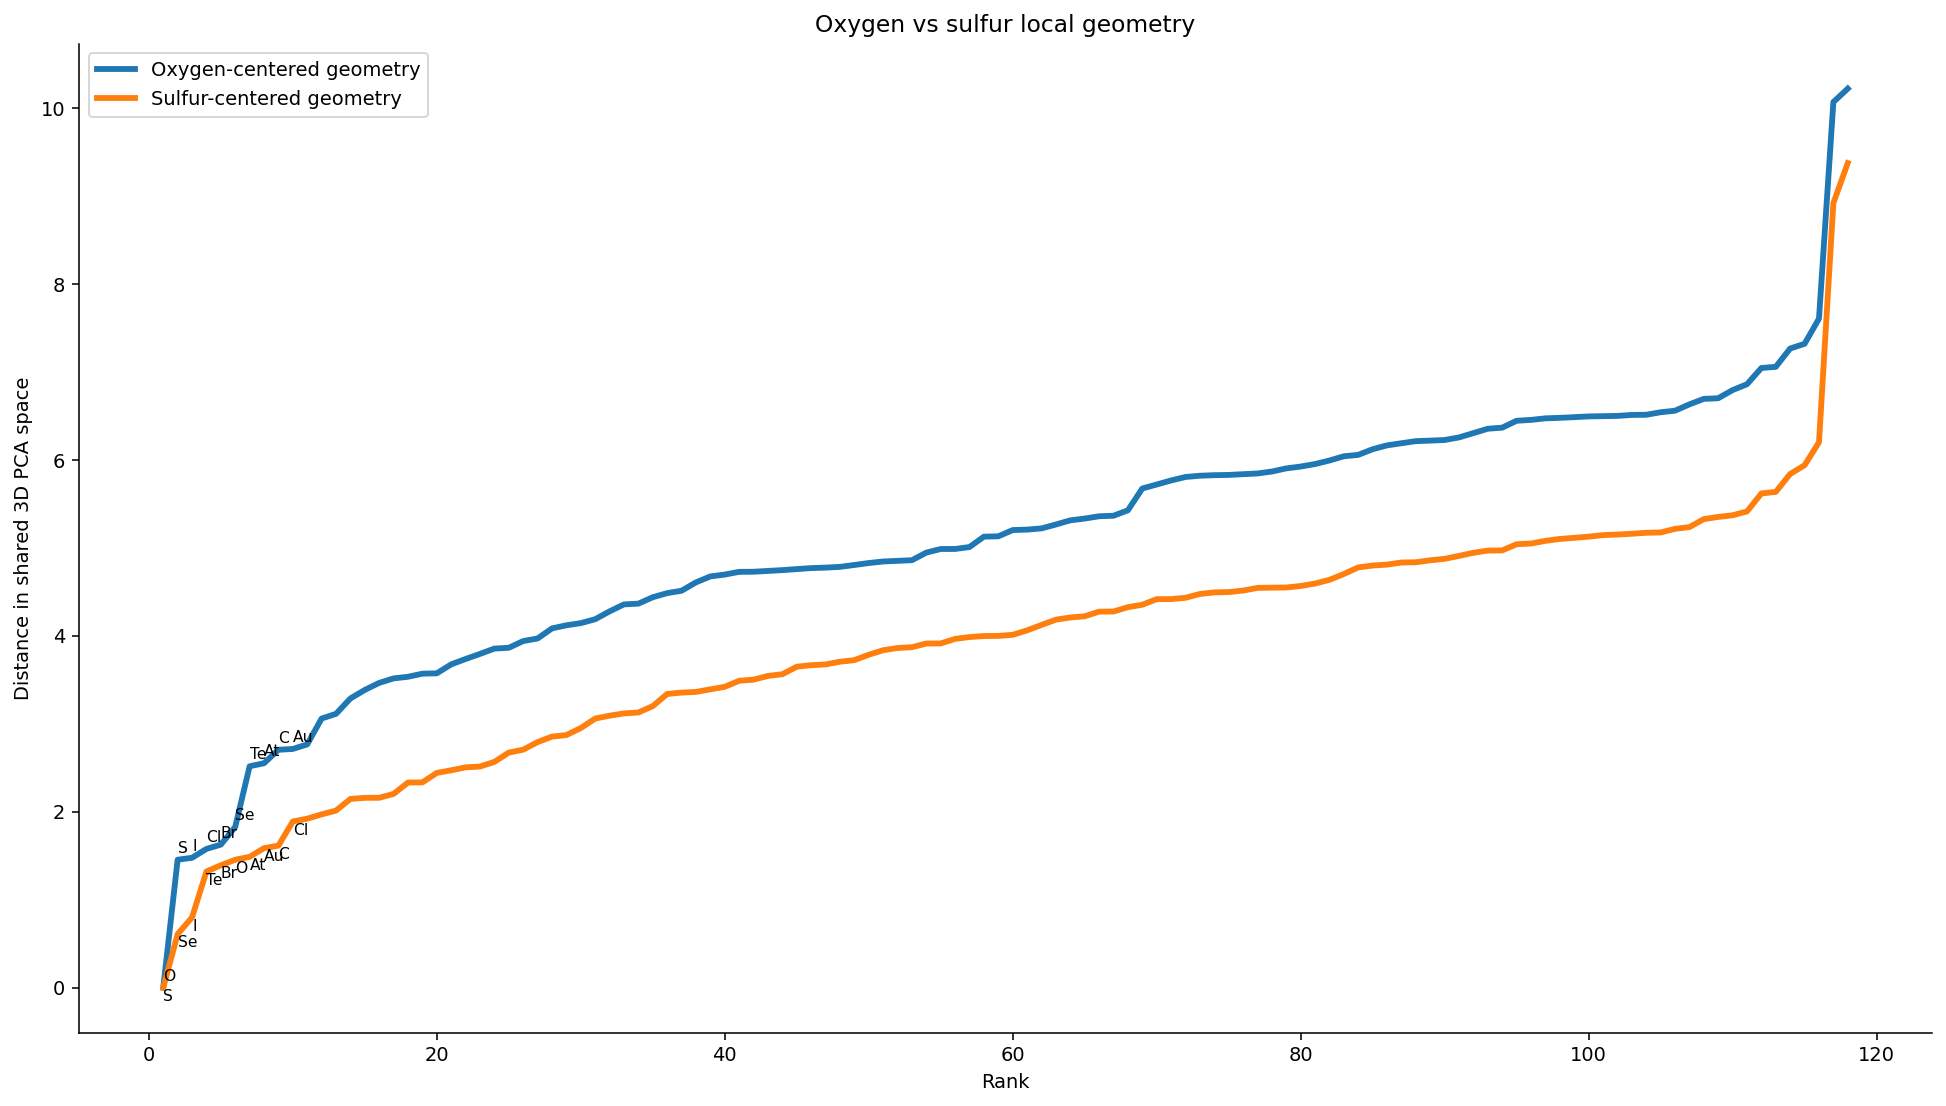

Saved:
- oxygen_vs_sulfur_summary.csv
- oxygen_vs_sulfur_geometry.png
- oxygen_vs_sulfur_geometry.pdf


In [28]:
comparison_os.to_csv("oxygen_vs_sulfur_summary.csv", index=False)

plt.figure(figsize=(14, 8))

plt.plot(
    range(1, len(oxygen_curve) + 1),
    oxygen_curve["distance_to_o_3d"],
    linewidth=3,
    label="Oxygen-centered geometry"
)

plt.plot(
    range(1, len(sulfur_curve) + 1),
    sulfur_curve["distance_to_s_3d"],
    linewidth=3,
    label="Sulfur-centered geometry"
)

for _, row in oxygen_curve.head(10).iterrows():
    plt.text(
        row["rank_around_O"],
        row["distance_to_o_3d"] + 0.08,
        row["element"],
        fontsize=8
    )

for _, row in sulfur_curve.head(10).iterrows():
    plt.text(
        row["rank_around_S"],
        row["distance_to_s_3d"] - 0.15,
        row["element"],
        fontsize=8
    )

plt.xlabel("Rank")
plt.ylabel("Distance in shared 3D PCA space")
plt.title("Oxygen vs sulfur local geometry")
plt.legend()
plt.tight_layout()

plt.savefig("oxygen_vs_sulfur_geometry.png", dpi=300, bbox_inches="tight")
plt.savefig("oxygen_vs_sulfur_geometry.pdf", dpi=300, bbox_inches="tight")

plt.show()

print("Saved:")
print("- oxygen_vs_sulfur_summary.csv")
print("- oxygen_vs_sulfur_geometry.png")
print("- oxygen_vs_sulfur_geometry.pdf")

## 10. Formal comparison between 2D and 3D rankings

In [29]:
oxygen_rank_2d = df_master.sort_values(
    "distance_to_oxygen_2d"
).reset_index(drop=True)

oxygen_rank_2d["oxygen_rank_2d"] = oxygen_rank_2d.index + 1

display(
    oxygen_rank_2d[
        ["oxygen_rank_2d", "element", "name", "distance_to_oxygen_2d"]
    ].head(15)
)

,oxygen_rank_2d,element,name,distance_to_oxygen_2d
0,1,O,Oxygen,0.000000
1,2,S,Sulfur,1.432734
2,3,I,Iodine,1.434086
3,4,Cl,Chlorine,1.476413
4,5,Br,Bromine,1.624957
5,6,Se,Selenium,1.816127
6,7,At,Astatine,2.436529
7,8,Te,Tellurium,2.467409
8,9,Au,Gold,2.662751
9,10,C,Carbon,2.682161


In [30]:
rank_compare = oxygen_rank_2d[["element", "oxygen_rank_2d"]].merge(
    oxygen_rank_3d[["element", "oxygen_rank_3d"]],
    on="element",
    how="inner"
)

rho, pval = spearmanr(rank_compare["oxygen_rank_2d"], rank_compare["oxygen_rank_3d"])

print("Spearman correlation (2D vs 3D):", rho)
print("p-value:", pval)

display(rank_compare.head())

Spearman correlation (2D vs 3D): 0.9909721385294665
p-value: 4.388845726506435e-103


,element,oxygen_rank_2d,oxygen_rank_3d
0,O,1,1
1,S,2,2
2,I,3,3
3,Cl,4,4
4,Br,5,5


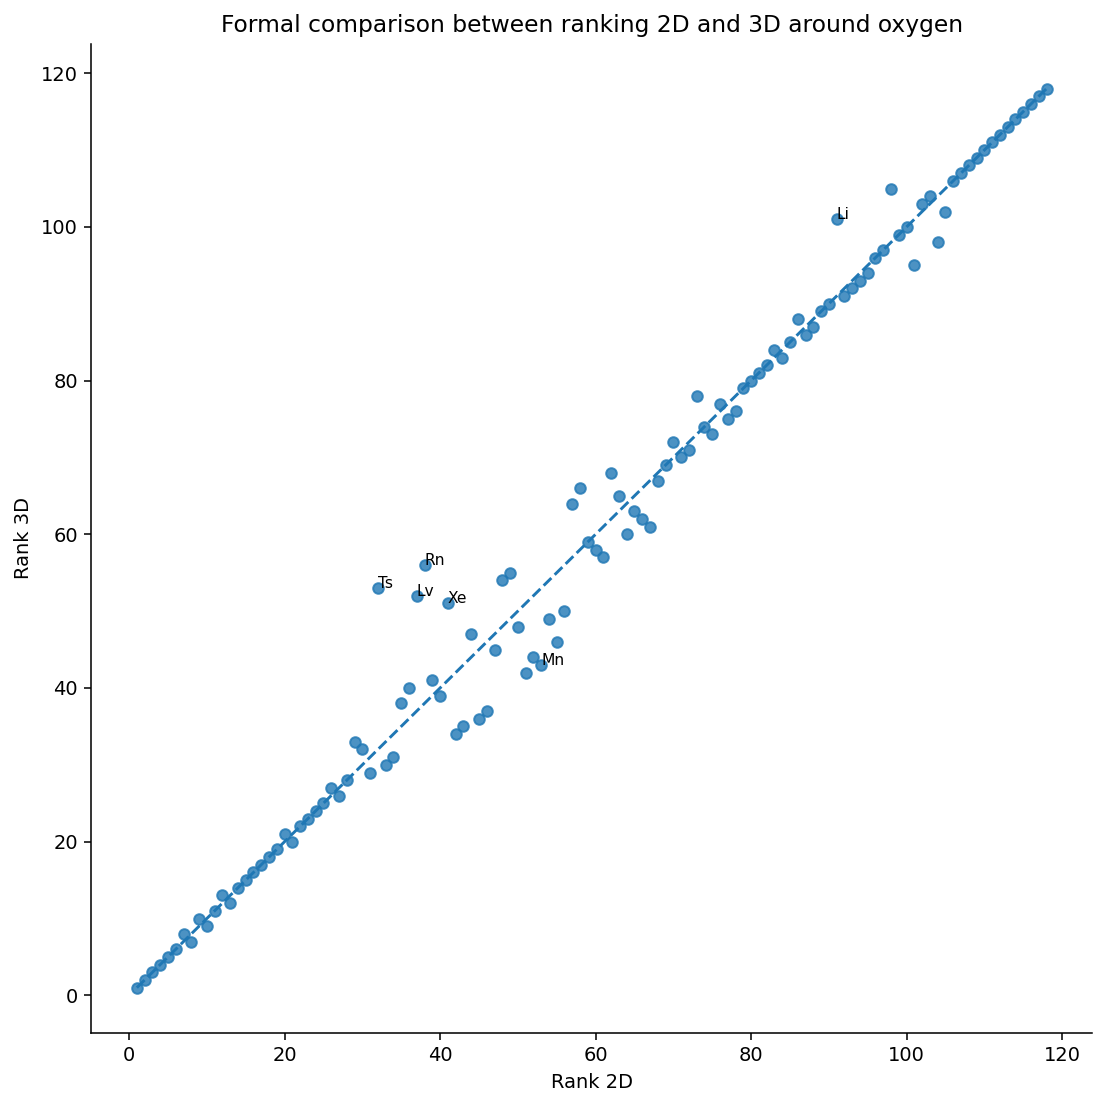

In [31]:
plt.figure(figsize=(8, 8))

plt.scatter(
    rank_compare["oxygen_rank_2d"],
    rank_compare["oxygen_rank_3d"],
    s=30,
    alpha=0.8
)

lims = [1, len(rank_compare)]
plt.plot(lims, lims, linestyle="--")

for _, row in rank_compare.iterrows():
    if abs(row["oxygen_rank_2d"] - row["oxygen_rank_3d"]) >= 10:
        el = row["element"]
        plt.text(
            row["oxygen_rank_2d"],
            row["oxygen_rank_3d"],
            el,
            fontsize=8
        )

plt.xlabel("Rank 2D")
plt.ylabel("Rank 3D")
plt.title("Formal comparison between ranking 2D and 3D around oxygen")
plt.tight_layout()
plt.show()

## 11. Export comparison tables

In [32]:
reference_compactness_df.to_csv("reference_compactness_summary.csv", index=False)
oxygen_overlap_df.to_csv("oxygen_overlap_summary.csv", index=False)
rank_compare.to_csv("oxygen_rank_2d_vs_3d.csv", index=False)

print("Saved:")
print("- reference_compactness_summary.csv")
print("- oxygen_overlap_summary.csv")
print("- oxygen_rank_2d_vs_3d.csv")

Saved:
- reference_compactness_summary.csv
- oxygen_overlap_summary.csv
- oxygen_rank_2d_vs_3d.csv


## 12. Final interpretation

In [33]:
print("""
Main findings

1. Oxygen generates a structured multivariable neighborhood across the periodic table.

2. Sulfur reproduces the full oxygen top-10 neighborhood and generates an even more compact local geometry.

3. Carbon produces a compact but more structural neighborhood, whereas nitrogen and hydrogen show substantially lower overlap with oxygen.

4. The oxygen-centered ranking remains broadly stable across 2D and 3D embeddings.

5. These results suggest that oxygen belongs to a broader oxygen-sulfur chemical family characterized by redox flexibility, catalytic behavior, and cross-regime connectivity.
""")


Main findings

1. Oxygen generates a structured multivariable neighborhood across the periodic table.

2. Sulfur reproduces the full oxygen top-10 neighborhood and generates an even more compact local geometry.

3. Carbon produces a compact but more structural neighborhood, whereas nitrogen and hydrogen show substantially lower overlap with oxygen.

4. The oxygen-centered ranking remains broadly stable across 2D and 3D embeddings.

5. These results suggest that oxygen belongs to a broader oxygen-sulfur chemical family characterized by redox flexibility, catalytic behavior, and cross-regime connectivity.



## 13. Download outputs

In [34]:
files_to_package = [
    "oxygen_centered_ranking_main.png",
    "oxygen_centered_ranking_main.pdf",
    "oxygen_centered_full_ranking.csv",
    "oxygen_top15_nearest.csv",
    "oxygen_top15_farthest.csv",
    "oxygen_regime_summary.csv",
    "oxygen_class_summary.csv",
    "oxygen_vs_sulfur_summary.csv",
    "oxygen_vs_sulfur_geometry.png",
    "oxygen_vs_sulfur_geometry.pdf",
    "reference_compactness_summary.csv",
    "oxygen_overlap_summary.csv",
    "oxygen_rank_2d_vs_3d.csv"
]

zip_name = "oxygen_centered_geometry_outputs.zip"

with zipfile.ZipFile(zip_name, "w") as zipf:
    for fname in files_to_package:
        if os.path.exists(fname):
            zipf.write(fname)

print("Created:", zip_name)

Created: oxygen_centered_geometry_outputs.zip


In [35]:
files.download("oxygen_centered_geometry_outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Optional downloads

The following cells can be used to download figures and tables generated by the notebook.

In [36]:
files.download("oxygen_centered_ranking_main.png")
files.download("oxygen_centered_full_ranking.csv")
files.download("oxygen_top15_nearest.csv")
files.download("oxygen_top15_farthest.csv")
files.download("oxygen_vs_sulfur_summary.csv")
files.download("oxygen_vs_sulfur_geometry.png")
files.download("reference_compactness_summary.csv")
files.download("oxygen_overlap_summary.csv")
files.download("oxygen_rank_2d_vs_3d.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>